# Autoencoder-Based Network Intrusion Detection on NSL-KDD

**AI for Cybersecurity, Module 3 Lab** · Ruthvik Nath Bandari · Northeastern University

This notebook builds an **unsupervised anomaly detector**: a small dense autoencoder is trained to
reconstruct *normal* network connections only. Anything it reconstructs badly is flagged as an
attack. Because the model never sees an attack during training, it can in principle catch attack
types nobody has labelled yet, which is the main reason anomaly detection matters in a SOC.

| Step | What happens |
|---|---|
| 1. Data | Load NSL-KDD, keep numerical features, train on normal traffic only, 80/20 train/validation split, StandardScaler |
| 2. Model | Autoencoder `n → 20 → 10 → 20 → n`, Adam + MSE, 50 epochs with early stopping, threshold = 95th percentile of training error |
| 3. Evaluation | Classification report, confusion matrix, ROC curve, Isolation Forest baseline, per-attack-type analysis |

**Dataset.** NSL-KDD (Tavallaee et al., 2009), the cleaned version of the KDD Cup 1999 data derived
from the DARPA/MIT Lincoln Laboratory intrusion detection evaluation. Official page:
<https://www.unb.ca/cic/datasets/nsl.html>. The files are identical to the UNB release; the cell
below downloads them from a public mirror so the notebook runs on Colab with *Runtime → Run all*.

In [1]:
import os, time, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # hide TensorFlow C++ info/warning logs
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, precision_recall_fscore_support)

SEED = 42
keras.utils.set_random_seed(SEED)          # seeds Python, NumPy and TensorFlow
tf.config.experimental.enable_op_determinism()

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", None)
print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


## Step 1 · Data loading and preprocessing

### 1.1 Load the data
NSL-KDD ships as headerless CSV files: 41 features, the attack label, and a difficulty score
(how many of 21 reference classifiers labelled the record *correctly*, so lower means harder). `KDDTrain+` is the training set and
`KDDTest+` is the official test set, which deliberately includes **17 attack types that never
appear in training**. That makes it a good test of whether an anomaly detector generalises.

In [2]:
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
MIRROR = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/"
for fname in ["KDDTrain+.txt", "KDDTest+.txt"]:
    if not (DATA_DIR / fname).exists():
        urllib.request.urlretrieve(MIRROR + fname, DATA_DIR / fname)

COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty",
]
train_df = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
test_df  = pd.read_csv(DATA_DIR / "KDDTest+.txt",  names=COLUMNS)

print(f"Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} cols")
print(f"Test : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols")
print("Missing values (train, test):", train_df.isna().sum().sum(), test_df.isna().sum().sum())
train_df.head()

Train: 125,973 rows x 43 cols
Test : 22,544 rows x 43 cols
Missing values (train, test): 0 0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.0000,0.0000,0.0300,0.0400,0.0300,0.0100,0.0000,0.0100,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,normal,21


### 1.2 Map attack labels to the four standard categories
Each specific attack belongs to one of the four families used throughout the KDD literature:
**DoS** (denial of service), **Probe** (scanning), **R2L** (remote-to-local, i.e. unauthorised access
from a remote machine) and **U2R** (user-to-root privilege escalation). The mapping covers the
test-only attacks as well. Published mappings disagree on a few test-only attacks (for example,
`httptunnel` is placed in U2R by some authors and R2L by others), so the small R2L and U2R figures
depend partly on this convention.

In [3]:
ATTACK_CATEGORY = {
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "mailbomb": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "mscan": "Probe", "saint": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L", "phf": "R2L",
    "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L", "sendmail": "R2L", "named": "R2L",
    "snmpgetattack": "R2L", "snmpguess": "R2L", "xlock": "R2L", "xsnoop": "R2L", "worm": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "httptunnel": "U2R", "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R",
}
for df in (train_df, test_df):
    df["category"] = df["label"].map(ATTACK_CATEGORY).fillna("Normal")
    df.loc[df["label"] == "normal", "category"] = "Normal"
    df["is_attack"] = (df["label"] != "normal").astype(int)

unmapped = set(test_df.loc[test_df["label"] != "normal", "label"]) - set(ATTACK_CATEGORY)
assert not unmapped, f"Unmapped labels: {unmapped}"

counts = pd.DataFrame({"train": train_df["category"].value_counts(),
                       "test": test_df["category"].value_counts()}).fillna(0).astype(int)
counts.loc["Total"] = counts.sum()
novel = sorted(set(test_df["label"]) - set(train_df["label"]))
print(f"Attack types in test but never in training ({len(novel)}): {', '.join(novel)}")
counts

Attack types in test but never in training (17): apache2, httptunnel, mailbomb, mscan, named, processtable, ps, saint, sendmail, snmpgetattack, snmpguess, sqlattack, udpstorm, worm, xlock, xsnoop, xterm


,train,test
category,,
DoS,45927,7458
Normal,67343,9711
Probe,11656,2421
R2L,995,2754
U2R,52,200
Total,125973,22544


### 1.3 Feature selection: numerical features only
The brief asks for numerical features only. Of the 41 NSL-KDD features, three are categorical
strings (`protocol_type`, `service`, `flag`) and are dropped. One more, `num_outbound_cmds`, is
zero in every training record, so it carries no information and is dropped as well. That leaves
**37 numerical features**, so the autoencoder's input and output layers have 37 units rather than
41 (the brief's "41" is the full NSL-KDD feature count, including the categorical columns).

In [4]:
CATEGORICAL = ["protocol_type", "service", "flag"]
META = ["label", "difficulty", "category", "is_attack"]
numeric = [c for c in COLUMNS if c not in CATEGORICAL + META]
constant = [c for c in numeric if train_df[c].nunique() == 1]
FEATURES = [c for c in numeric if c not in constant]

print(f"41 features -> drop {len(CATEGORICAL)} categorical -> {len(numeric)} numerical "
      f"-> drop constant {constant} -> {len(FEATURES)} used")
train_df[FEATURES].describe().T[["mean", "std", "min", "50%", "max"]].head(12)

41 features -> drop 3 categorical -> 38 numerical -> drop constant ['num_outbound_cmds'] -> 37 used


,mean,std,min,50%,max
duration,287.1447,2604.5153,0.0000,0.0000,42908.0000
src_bytes,45566.7430,5870331.1819,0.0000,44.0000,1379963888.0000
dst_bytes,19779.1144,4021269.1514,0.0000,0.0000,1309937401.0000
land,0.0002,0.0141,0.0000,0.0000,1.0000
wrong_fragment,0.0227,0.2535,0.0000,0.0000,3.0000
urgent,0.0001,0.0144,0.0000,0.0000,3.0000
hot,0.2044,2.1500,0.0000,0.0000,77.0000
num_failed_logins,0.0012,0.0452,0.0000,0.0000,5.0000
logged_in,0.3957,0.4890,0.0000,0.0000,1.0000
num_compromised,0.2793,23.9420,0.0000,0.0000,7479.0000


### 1.4 Handle heavy-tailed features
`src_bytes` has a median of 44 but a maximum above a billion. StandardScaler divides by the
standard deviation, which such outliers inflate enormously, so almost every normal record would
be squashed to about 0, which makes their structure harder for the model to learn. A `log1p` transform is applied
first to every non-negative count or byte feature whose maximum exceeds 1 (rates and binary flags
are already in [0, 1] and are left alone). StandardScaler is still the normaliser; `log1p` only
makes its mean and standard deviation meaningful. Section 3.7 checks that this helps.

**Which data these choices look at.** The constant-column and `log1p` decisions look at the whole
training file *without its labels*. They never see the test set or any label. Deciding them from the normal records
alone would be stricter, but it would drop `wrong_fragment`: that feature is zero in every normal
training record, yet it is non-zero in every `teardrop` record and 88% of `pod` records
(checked in Section 3.6). A feature that never varies in normal traffic is worth keeping for an anomaly detector.

In [5]:
LOG_COLS = [c for c in FEATURES if train_df[c].max() > 1]
print(f"log1p applied to {len(LOG_COLS)} features: {LOG_COLS}")

def to_matrix(df, log=True):
    X = df[FEATURES].astype("float64").copy()
    if log:
        X[LOG_COLS] = np.log1p(X[LOG_COLS])
    return X.values

skew_before = train_df[LOG_COLS].skew().abs().mean()
skew_after = pd.DataFrame(to_matrix(train_df), columns=FEATURES)[LOG_COLS].skew().abs().mean()
print(f"Mean |skew| of those features: {skew_before:.1f} -> {skew_after:.1f}")

log1p applied to 17 features: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']
Mean |skew| of those features: 83.4 -> 23.8


### 1.5 Normal-only training data, 80/20 split, standardisation
Only `normal` training records are used to fit the model. They are split 80% train / 20%
validation first, and the scaler is then fitted on the 80% training portion only. Fitting the scaler on
the full set before splitting would leak validation statistics into training. Validation data is
used for early stopping and for checking the false-positive rate of the threshold.

The test set is the full `KDDTest+` file (normal plus all four attack categories), transformed with the
**same** scaler fitted on normal training data.

In [6]:
normal_train = train_df[train_df["is_attack"] == 0]
X_normal = to_matrix(normal_train)
X_tr_raw, X_val_raw = train_test_split(X_normal, test_size=0.20, random_state=SEED, shuffle=True)

scaler = StandardScaler().fit(X_tr_raw)
X_train = scaler.transform(X_tr_raw).astype("float32")
X_val   = scaler.transform(X_val_raw).astype("float32")
X_test  = scaler.transform(to_matrix(test_df)).astype("float32")
y_test  = test_df["is_attack"].values
cat_test = test_df["category"].values

print(f"Normal training records: {len(X_normal):,}  (attacks excluded: {train_df['is_attack'].sum():,})")
print(f"  train      : {X_train.shape}")
print(f"  validation : {X_val.shape}")
print(f"Test (mixed) : {X_test.shape}  normal={int((y_test==0).sum()):,}  attack={int(y_test.sum()):,}")
print(f"Scaled train mean ~ {X_train.mean():.3f}, std ~ {X_train.std():.3f}")

Normal training records: 67,343  (attacks excluded: 58,630)
  train      : (53874, 37)
  validation : (13469, 37)
Test (mixed) : (22544, 37)  normal=9,711  attack=12,833
Scaled train mean ~ -0.000, std ~ 0.986


## Step 2 · Autoencoder implementation

### 2.1 Architecture
Input (37) → Dense(20, ReLU) → **Dense(10, ReLU) bottleneck** → Dense(20, ReLU) → Output(37, linear).
The 10-unit bottleneck forces the network to learn a compressed description of *normal*
behaviour. The output is linear because standardised features can be negative.

In [7]:
N_FEATURES = X_train.shape[1]

def build_autoencoder(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(20, activation="relu", name="encoder_1"),
        layers.Dense(10, activation="relu", name="bottleneck"),
        layers.Dense(20, activation="relu", name="decoder_1"),
        layers.Dense(n_features, activation="linear", name="reconstruction"),
    ], name="nslkdd_autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

autoencoder = build_autoencoder(N_FEATURES)
autoencoder.summary()

Model: "nslkdd_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Dense)               │ (None, 20)             │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 37)             │           777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,967 (7.68 KB)

 Trainable params: 1,967 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Train on normal traffic only
Up to 50 epochs, batch size 256. The input is also the target. Early stopping watches validation loss
with a patience of 5 epochs and restores the best weights, so the model is not over-fitted to the
training records.

In [8]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                           restore_best_weights=True, verbose=1)
t0 = time.time()
history = autoencoder.fit(X_train, X_train,
                          validation_data=(X_val, X_val),
                          epochs=50, batch_size=256, shuffle=True,
                          callbacks=[early_stop], verbose=2)
hist = pd.DataFrame(history.history)
best_epoch = int(hist["val_loss"].idxmin()) + 1
print(f"\nTrained {len(hist)} epochs in {time.time()-t0:.0f}s; best epoch {best_epoch} "
      f"(val MSE {hist['val_loss'].min():.4f}); train MSE fell {hist['loss'].iloc[0]:.4f} -> {hist['loss'].iloc[-1]:.4f}")

Epoch 1/50
211/211 - 6s - 27ms/step - loss: 0.7860 - val_loss: 0.5303
Epoch 2/50
211/211 - 1s - 5ms/step - loss: 0.5025 - val_loss: 0.3941
Epoch 3/50
211/211 - 1s - 5ms/step - loss: 0.3908 - val_loss: 0.3329
Epoch 4/50
211/211 - 1s - 5ms/step - loss: 0.3459 - val_loss: 0.2991
Epoch 5/50
211/211 - 1s - 7ms/step - loss: 0.3178 - val_loss: 0.2725
Epoch 6/50
211/211 - 2s - 11ms/step - loss: 0.2942 - val_loss: 0.2486
Epoch 7/50
211/211 - 1s - 5ms/step - loss: 0.2737 - val_loss: 0.2298
Epoch 8/50
211/211 - 1s - 5ms/step - loss: 0.2574 - val_loss: 0.2153
Epoch 9/50
211/211 - 1s - 5ms/step - loss: 0.2452 - val_loss: 0.2060
Epoch 10/50
211/211 - 1s - 5ms/step - loss: 0.2359 - val_loss: 0.1982
Epoch 11/50
211/211 - 1s - 5ms/step - loss: 0.2282 - val_loss: 0.1935
Epoch 12/50
211/211 - 1s - 5ms/step - loss: 0.2213 - val_loss: 0.1876
Epoch 13/50
211/211 - 1s - 5ms/step - loss: 0.2151 - val_loss: 0.1829
Epoch 14/50
211/211 - 1s - 6ms/step - loss: 0.2096 - val_loss: 0.1786
Epoch 15/50
211/211 - 2s - 

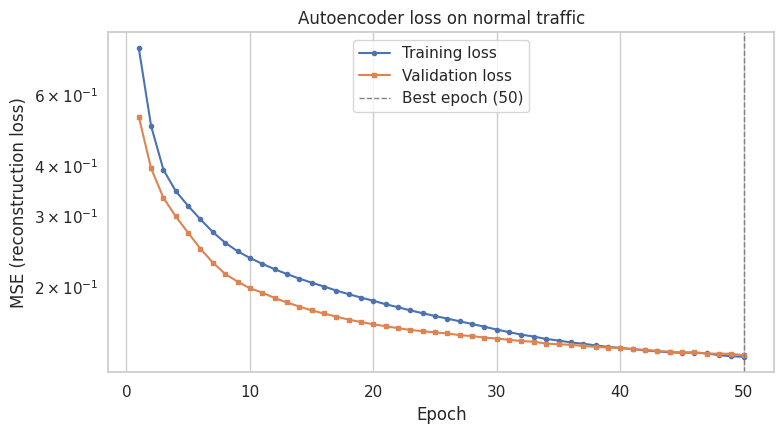

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = np.arange(1, len(hist) + 1)
ax.plot(epochs, hist["loss"], marker="o", ms=3, label="Training loss")
ax.plot(epochs, hist["val_loss"], marker="s", ms=3, label="Validation loss")
ax.axvline(best_epoch, color="grey", ls="--", lw=1, label=f"Best epoch ({best_epoch})")
ax.set(xlabel="Epoch", ylabel="MSE (reconstruction loss)", yscale="log",
       title="Autoencoder loss on normal traffic")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig1_loss_curve.png", dpi=200); plt.show()

### 2.3 Reconstruction-error threshold
The anomaly score of a record is its mean squared reconstruction error across the 37 features. Following the
brief, the threshold is the **95th percentile of training-set errors**, meaning 5% of the normal
training traffic would be flagged by design. The validation set, which the threshold never saw, checks
that this false-positive rate holds on unseen normal data.

In [10]:
def reconstruction_error(model, X):
    recon = model.predict(X, batch_size=2048, verbose=0)
    return np.mean(np.square(X - recon), axis=1)

err_train = reconstruction_error(autoencoder, X_train)
err_val   = reconstruction_error(autoencoder, X_val)
err_test  = reconstruction_error(autoencoder, X_test)

THRESHOLD = np.percentile(err_train, 95)
print(f"Threshold (95th pct of training error): {THRESHOLD:.4f}")
print(f"Flagged: train {np.mean(err_train > THRESHOLD):.2%} | validation {np.mean(err_val > THRESHOLD):.2%} (normal data)")

Threshold (95th pct of training error): 0.4949
Flagged: train 5.00% | validation 5.02% (normal data)


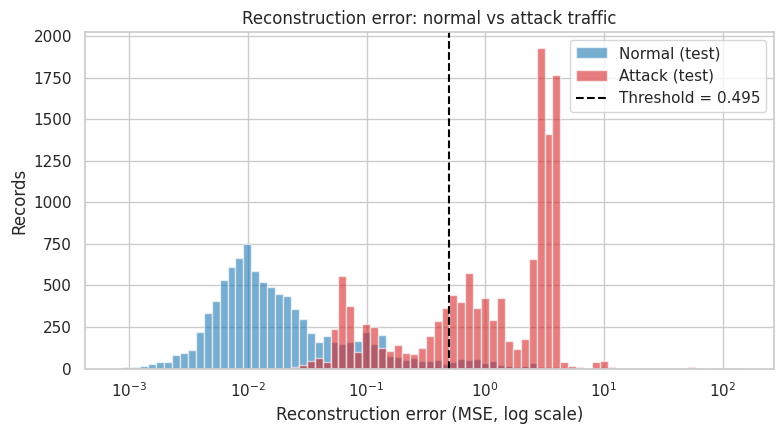

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.logspace(np.log10(max(err_test.min(), 1e-4)), np.log10(err_test.max()), 80)
ax.hist(err_test[y_test == 0], bins=bins, alpha=0.6, label="Normal (test)", color="tab:blue")
ax.hist(err_test[y_test == 1], bins=bins, alpha=0.6, label="Attack (test)", color="tab:red")
ax.axvline(THRESHOLD, color="black", ls="--", label=f"Threshold = {THRESHOLD:.3f}")
ax.set(xscale="log", xlabel="Reconstruction error (MSE, log scale)", ylabel="Records",
       title="Reconstruction error: normal vs attack traffic")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_error_distribution.png", dpi=200); plt.show()

### 2.4 Classify the mixed test set
Records with an error above the threshold are labelled **attack**.

In [12]:
y_pred_ae = (err_test > THRESHOLD).astype(int)
print(f"Flagged {y_pred_ae.sum():,} of {len(y_pred_ae):,} test records as anomalous")

Flagged 9,787 of 22,544 test records as anomalous


## Step 3 · Evaluation and analysis

### 3.1 Classification report

In [13]:
print("Autoencoder, threshold = 95th percentile of training error\n")
print(classification_report(y_test, y_pred_ae, target_names=["Normal", "Attack"], digits=4))

def summarise(name, y_true, y_pred, scores):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"model": name, "precision": p, "recall": r, "f1": f,
            "false_pos_rate": fp / (fp + tn), "accuracy": (tp + tn) / len(y_true),
            "roc_auc": roc_auc_score(y_true, scores), "pr_auc": average_precision_score(y_true, scores)}

ae_summary = summarise("Autoencoder", y_test, y_pred_ae, err_test)
pd.Series(ae_summary)

Autoencoder, threshold = 95th percentile of training error

              precision    recall  f1-score   support

      Normal     0.7282    0.9566    0.8270      9711
      Attack     0.9570    0.7298    0.8281     12833

    accuracy                         0.8275     22544
   macro avg     0.8426    0.8432    0.8275     22544
weighted avg     0.8584    0.8275    0.8276     22544



,0
model,Autoencoder
precision,0.9570
recall,0.7298
f1,0.8281
false_pos_rate,0.0434
accuracy,0.8275
roc_auc,0.9582
pr_auc,0.9582


### 3.2 Confusion matrix and ROC curve

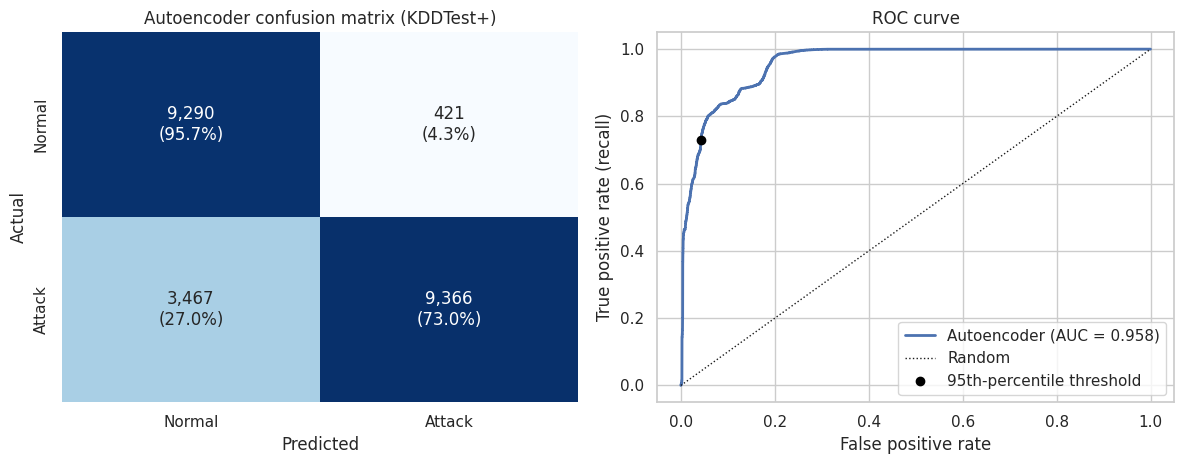

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
cm = confusion_matrix(y_test, y_pred_ae)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1%})" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
axes[0].set(xlabel="Predicted", ylabel="Actual", title="Autoencoder confusion matrix (KDDTest+)")

fpr, tpr, _ = roc_curve(y_test, err_test)
op_fpr, op_tpr = ae_summary["false_pos_rate"], ae_summary["recall"]
axes[1].plot(fpr, tpr, lw=2, label=f"Autoencoder (AUC = {ae_summary['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k:", lw=1, label="Random")
axes[1].scatter([op_fpr], [op_tpr], color="black", zorder=5, label="95th-percentile threshold")
axes[1].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curve")
axes[1].legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_confusion_roc.png", dpi=200); plt.show()

### 3.3 Threshold sensitivity
The 95th percentile is a policy choice: it fixes a false-positive budget of about 5% on normal
traffic. The table shows what other budgets would buy, all computed from training errors only (no
test labels are used to pick them).

In [15]:
rows = []
for pct in [90, 95, 97.5, 99, 99.5]:
    thr = np.percentile(err_train, pct)
    pred = (err_test > thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="binary")
    fp_rate = np.mean(pred[y_test == 0])
    rows.append({"train percentile": pct, "threshold": thr, "precision": p, "recall": r,
                 "f1": f, "test FPR": fp_rate})
sens = pd.DataFrame(rows).set_index("train percentile")
sens

,threshold,precision,recall,f1,test FPR
train percentile,,,,,
90.0000,0.2572,0.9446,0.8057,0.8696,0.0625
95.0000,0.4949,0.9570,0.7298,0.8281,0.0434
97.5000,0.9574,0.9730,0.5804,0.7271,0.0213
99.0000,2.2389,0.9849,0.4679,0.6344,0.0095
99.5000,2.7302,0.9915,0.4082,0.5784,0.0046


### 3.4 Baseline: Isolation Forest
Isolation Forest is a classical statistical outlier detector. It isolates points with random
splits, and outliers need fewer splits. For a fair comparison it gets **exactly the same inputs**:
the same normal-only training records, the same preprocessing, and the same thresholding rule (95th
percentile of its own training scores).

In [16]:
t0 = time.time()
iso = IsolationForest(n_estimators=200, max_samples=256, random_state=SEED, n_jobs=-1).fit(X_train)
score_train_if = -iso.score_samples(X_train)    # higher = more anomalous
score_test_if  = -iso.score_samples(X_test)
thr_if = np.percentile(score_train_if, 95)
y_pred_if = (score_test_if > thr_if).astype(int)
print(f"Isolation Forest fitted in {time.time()-t0:.1f}s\n")
print(classification_report(y_test, y_pred_if, target_names=["Normal", "Attack"], digits=4))

if_summary = summarise("Isolation Forest", y_test, y_pred_if, score_test_if)
comparison = pd.DataFrame([ae_summary, if_summary]).set_index("model")
comparison

Isolation Forest fitted in 1.7s

              precision    recall  f1-score   support

      Normal     0.6846    0.9753    0.8045      9711
      Attack     0.9724    0.6600    0.7863     12833

    accuracy                         0.7958     22544
   macro avg     0.8285    0.8177    0.7954     22544
weighted avg     0.8485    0.7958    0.7942     22544



,precision,recall,f1,false_pos_rate,accuracy,roc_auc,pr_auc
model,,,,,,,
Autoencoder,0.9570,0.7298,0.8281,0.0434,0.8275,0.9582,0.9582
Isolation Forest,0.9724,0.6600,0.7863,0.0247,0.7958,0.9390,0.9553


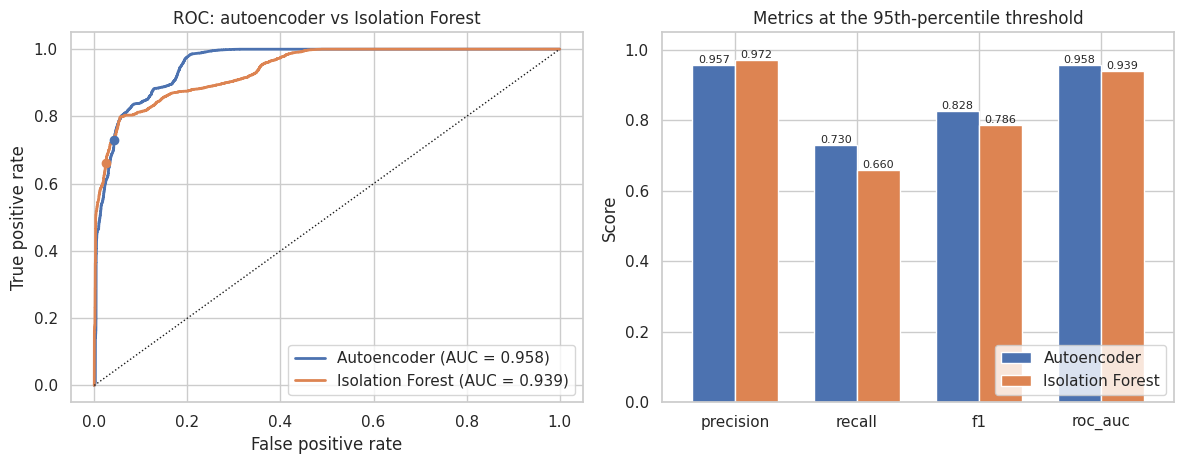

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name, scores, s in [("Autoencoder", err_test, ae_summary), ("Isolation Forest", score_test_if, if_summary)]:
    f_, t_, _ = roc_curve(y_test, scores)
    axes[0].plot(f_, t_, lw=2, label=f"{name} (AUC = {s['roc_auc']:.3f})")
    axes[0].scatter([s["false_pos_rate"]], [s["recall"]], zorder=5)
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC: autoencoder vs Isolation Forest")
axes[0].legend(loc="lower right")

metrics = ["precision", "recall", "f1", "roc_auc"]
comparison[metrics].T.plot.bar(ax=axes[1], rot=0, width=0.7)
axes[1].set(ylim=(0, 1.05), ylabel="Score", title="Metrics at the 95th-percentile threshold")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.3f", fontsize=8)
axes[1].legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig4_model_comparison.png", dpi=200); plt.show()

The two detectors land at different false-positive rates (the same 95th-percentile rule produces
different test FPRs), so the operating-point metrics above are not a like-for-like comparison. The ROC curves
allow one: the table reads off each model's detection rate at the same fixed false-positive budgets.

In [18]:
def tpr_at_fpr(scores, budgets=(0.01, 0.025, 0.05, 0.10)):
    f_, t_, _ = roc_curve(y_test, scores)
    return [np.interp(b, f_, t_) for b in budgets]

matched = pd.DataFrame({"Autoencoder": tpr_at_fpr(err_test), "Isolation Forest": tpr_at_fpr(score_test_if)},
                       index=["recall @ 1% FPR", "recall @ 2.5% FPR", "recall @ 5% FPR", "recall @ 10% FPR"])
matched

,Autoencoder,Isolation Forest
recall @ 1% FPR,0.4808,0.5614
recall @ 2.5% FPR,0.6086,0.6627
recall @ 5% FPR,0.7760,0.7658
recall @ 10% FPR,0.8403,0.8138


### 3.5 Which attack types are detected best and worst?
Aggregate metrics hide the important part: an IDS that catches every DoS flood but misses every
privilege escalation is not a safe IDS. Recall (detection rate) is broken down by category and
by individual attack type.

In [19]:
res = pd.DataFrame({"label": test_df["label"], "category": cat_test, "novel": test_df["label"].isin(novel),
                    "ae": y_pred_ae, "iforest": y_pred_if, "err": err_test})

by_cat = (res.groupby("category")
             .agg(records=("ae", "size"), ae_detect=("ae", "mean"), if_detect=("iforest", "mean"),
                  median_error=("err", "median"))
             .reindex(["Normal", "DoS", "Probe", "R2L", "U2R"]))
by_cat = by_cat.rename(columns={"ae_detect": "AE flagged", "if_detect": "IForest flagged"})
print("Share of records flagged (for Normal this is the false-positive rate; for attacks it is recall)")
by_cat

Share of records flagged (for Normal this is the false-positive rate; for attacks it is recall)


,records,AE flagged,IForest flagged,median_error
category,,,,
Normal,9711,0.0434,0.0247,0.0137
DoS,7458,0.8552,0.8009,2.9477
Probe,2421,0.8145,0.9137,2.2253
R2L,2754,0.3184,0.0672,0.1783
U2R,200,0.6950,0.5000,0.6412


In [20]:
attacks = res[res["category"] != "Normal"]
by_type = (attacks.groupby(["label", "category"])
                  .agg(records=("ae", "size"), ae_recall=("ae", "mean"), if_recall=("iforest", "mean"),
                       novel=("novel", "first"))
                  .reset_index().sort_values("ae_recall", ascending=False))
print("Per-attack-type recall (types with >= 20 test records)")
by_type[by_type["records"] >= 20].reset_index(drop=True)

Per-attack-type recall (types with >= 20 test records)


,label,category,records,ae_recall,if_recall,novel
0,nmap,Probe,73,1.0000,1.0000,False
1,neptune,DoS,4657,0.9996,1.0000,False
2,apache2,DoS,737,0.9430,0.9267,True
3,back,DoS,359,0.9387,0.0000,False
4,portsweep,Probe,157,0.9236,0.9936,False
5,satan,Probe,735,0.9088,0.9959,False
6,processtable,DoS,685,0.9051,0.8730,True
7,buffer_overflow,U2R,20,0.8500,0.6500,False
8,mscan,Probe,996,0.7902,0.9779,True
9,warezmaster,R2L,944,0.7331,0.1716,False


In [21]:
seen_novel = (attacks.groupby("novel")[["ae", "iforest"]].mean()
                     .rename(index={False: "Attack type seen in training", True: "Novel attack type (test only)"},
                             columns={"ae": "AE recall", "iforest": "IForest recall"}))
seen_novel["records"] = attacks.groupby("novel").size().values
seen_novel

,AE recall,IForest recall,records
novel,,,
Attack type seen in training,0.7567,0.6476,9083
Novel attack type (test only),0.6648,0.6901,3750


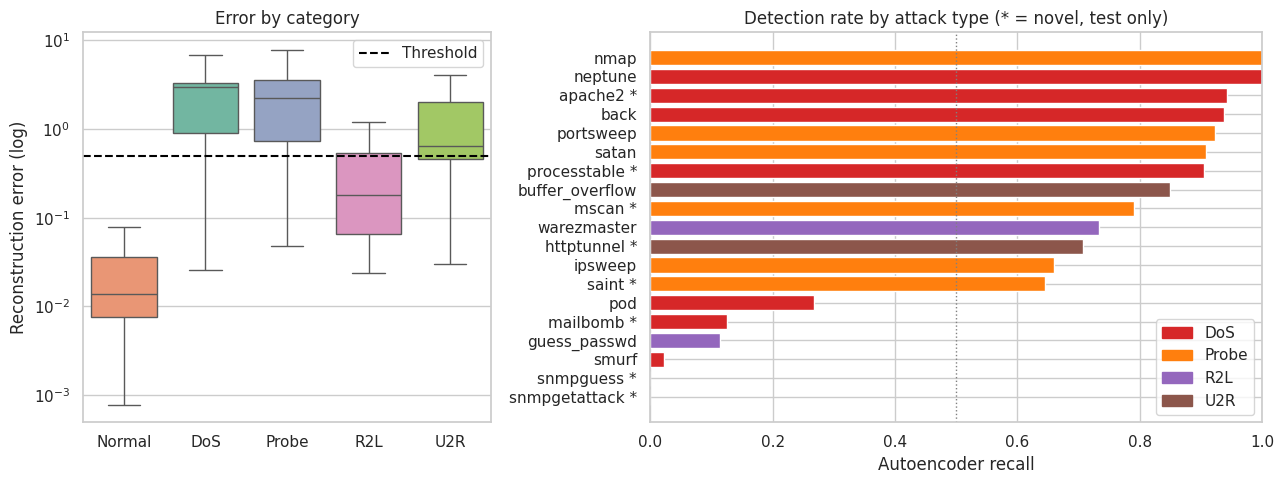

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.5]})
order = ["Normal", "DoS", "Probe", "R2L", "U2R"]
sns.boxplot(data=res, x="category", y="err", order=order, ax=axes[0], showfliers=False,
            hue="category", palette="Set2", legend=False)
axes[0].axhline(THRESHOLD, color="black", ls="--", label="Threshold")
axes[0].set(yscale="log", xlabel="", ylabel="Reconstruction error (log)", title="Error by category")
axes[0].legend()

plot_types = by_type[by_type["records"] >= 20].sort_values("ae_recall")
colors = plot_types["category"].map({"DoS": "tab:red", "Probe": "tab:orange", "R2L": "tab:purple", "U2R": "tab:brown"})
axes[1].barh(plot_types["label"] + np.where(plot_types["novel"], " *", ""), plot_types["ae_recall"], color=colors)
axes[1].axvline(0.5, color="grey", ls=":", lw=1)
axes[1].set(xlim=(0, 1), xlabel="Autoencoder recall", title="Detection rate by attack type (* = novel, test only)")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in
                        {"DoS": "tab:red", "Probe": "tab:orange", "R2L": "tab:purple", "U2R": "tab:brown"}.items()],
               loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig5_attack_type_recall.png", dpi=200); plt.show()

### 3.6 Why are some attacks invisible? Feature-level reconstruction error
The per-feature squared error shows *which* features the autoencoder fails to reconstruct for each
category, and so which behaviour gives an attack away.

In [23]:
sq_err = np.square(X_test - autoencoder.predict(X_test, batch_size=2048, verbose=0))
feat_err = pd.DataFrame(sq_err, columns=FEATURES).groupby(cat_test).mean().reindex(order)
top = {cat: ", ".join(f"{f} ({v:.1f})" for f, v in feat_err.loc[cat].nlargest(3).items()) for cat in order}
pd.DataFrame.from_dict(top, orient="index", columns=["Top-3 features by mean squared error"])

,Top-3 features by mean squared error
Normal,"root_shell (0.5), num_access_files (0.4), dst_host_diff_srv_rate (0.3)"
DoS,"same_srv_rate (18.4), src_bytes (8.0), count (6.9)"
Probe,"dst_host_srv_rerror_rate (12.0), srv_rerror_rate (10.2), rerror_rate (10.1)"
R2L,"num_access_files (3.3), hot (2.6), is_guest_login (1.6)"
U2R,"root_shell (45.4), num_access_files (28.9), is_host_login (17.7)"


The next cell checks the explanations used in the findings directly against the raw data, so
each claim about a missed (or caught) attack is backed by a computed number.

In [24]:
normal_test_vectors = set(map(tuple, test_df.loc[test_df["label"] == "normal", FEATURES].values))

def share_identical_to_normal(label):
    rows = test_df.loc[test_df["label"] == label, FEATURES].values
    return np.mean([tuple(r) in normal_test_vectors for r in rows])

def by_label(df, label):
    return df[df["label"] == label]

normal_tr = train_df[train_df["label"] == "normal"]
normal_icmp_echo = normal_tr[normal_tr["service"] == "ecr_i"]
smurf_bytes = by_label(test_df, "smurf")["src_bytes"].median()

evidence = pd.DataFrame([
    ("snmpgetattack", "share of records whose 37 features exactly match a normal test record",
     f"{share_identical_to_normal('snmpgetattack'):.1%}"),
    ("snmpguess", "share of records whose 37 features exactly match a normal test record",
     f"{share_identical_to_normal('snmpguess'):.1%}"),
    ("guess_passwd", "share of records with num_failed_logins > 0",
     f"{(by_label(test_df, 'guess_passwd')['num_failed_logins'] > 0).mean():.1%}"),
    ("smurf", "median src_bytes (smurf) vs normal ICMP echo (ecr_i) in training",
     f"{smurf_bytes:,.0f} vs {normal_icmp_echo['src_bytes'].median():,.0f}"),
    ("smurf", "percentile of that smurf median among ALL normal training src_bytes",
     f"{(normal_tr['src_bytes'] < smurf_bytes).mean():.0%}"),
    ("teardrop / pod", "share of records with wrong_fragment > 0 (normal training: "
     f"{(normal_tr['wrong_fragment'] > 0).mean():.0%})",
     f"{(by_label(test_df, 'teardrop')['wrong_fragment'] > 0).mean():.0%} / "
     f"{(by_label(test_df, 'pod')['wrong_fragment'] > 0).mean():.0%}"),
], columns=["attack", "check", "value"])
evidence

,attack,check,value
0,snmpgetattack,share of records whose 37 features exactly match a normal test record,30.3%
1,snmpguess,share of records whose 37 features exactly match a normal test record,0.0%
2,guess_passwd,share of records with num_failed_logins > 0,37.9%
3,smurf,median src_bytes (smurf) vs normal ICMP echo (ecr_i) in training,"1,008 vs 30"
4,smurf,percentile of that smurf median among ALL normal training src_bytes,88%
5,teardrop / pod,share of records with wrong_fragment > 0 (normal training: 0%),100% / 88%


### 3.7 Ablation: does the `log1p` step matter?
The same architecture and training settings, retrained on features scaled with StandardScaler only (no `log1p`),
to test the preprocessing decision in 1.4.

In [25]:
keras.utils.set_random_seed(SEED)
sc_raw = StandardScaler().fit(train_test_split(to_matrix(normal_train, log=False), test_size=0.20,
                                               random_state=SEED)[0])
Xn_raw = sc_raw.transform(to_matrix(normal_train, log=False)).astype("float32")
Xtr_r, Xva_r = train_test_split(Xn_raw, test_size=0.20, random_state=SEED)
Xte_r = sc_raw.transform(to_matrix(test_df, log=False)).astype("float32")

ae_raw = build_autoencoder(N_FEATURES)
ae_raw.fit(Xtr_r, Xtr_r, validation_data=(Xva_r, Xva_r), epochs=50, batch_size=256,
           callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
           verbose=0)
e_tr_r, e_te_r = reconstruction_error(ae_raw, Xtr_r), reconstruction_error(ae_raw, Xte_r)
raw_summary = summarise("Autoencoder, StandardScaler only", y_test,
                        (e_te_r > np.percentile(e_tr_r, 95)).astype(int), e_te_r)
ablation = pd.DataFrame([dict(ae_summary, model="Autoencoder, log1p + StandardScaler"), raw_summary]).set_index("model")
ablation[["precision", "recall", "f1", "false_pos_rate", "roc_auc"]]

,precision,recall,f1,false_pos_rate,roc_auc
model,,,,,
"Autoencoder, log1p + StandardScaler",0.9570,0.7298,0.8281,0.0434,0.9582
"Autoencoder, StandardScaler only",0.9578,0.7184,0.8210,0.0418,0.9373


## Findings

All numbers below are taken from the saved outputs above (Google Colab, TensorFlow 2.20, `SEED = 42`). Re-running on a
different TensorFlow version can shift them slightly.

**1. Training on normal traffic only worked as intended.** Training MSE fell from 0.786 to 0.134 over 50 epochs,
and validation MSE followed it (0.530 → 0.135). The two curves converge without a gap opening, so there is no sign
of over-fitting in this run. Validation loss was still improving slowly at epoch 50, so early stopping never had
to fire. The 95th-percentile threshold (MSE = 0.495) flagged 5.02% of the *unseen* normal validation records, close
to the intended 5% false-positive budget.

**2. Overall detection.** On the 22,544-record `KDDTest+` set, the autoencoder reached **precision 0.957, recall
0.730, F1 0.828 and ROC-AUC 0.958**, with a 4.3% false-positive rate. Its alerts are nearly always correct, but it
misses about a quarter of attacks. The threshold table (3.3) shows the trade-off a SOC would tune. The 90th
percentile raises recall to 0.806 (F1 0.870) at a 6.3% false-positive rate. The 99th percentile cuts false positives to
0.95% but catches fewer than half of attacks (0.468).

**3. Autoencoder vs Isolation Forest.** The autoencoder is better on ROC-AUC (0.958 vs 0.939) and on F1 at the
prescribed threshold (0.828 vs 0.786). The comparison is not one-sided, though, because the same rule gives the two
models different false-positive rates (4.3% vs 2.5%), and Isolation Forest has the higher precision (0.972 vs 0.957). Reading both ROC curves at fixed budgets, Isolation Forest is
better when alerts must be rare (56% vs 48% recall at 1% FPR). The autoencoder is slightly ahead from about 5% FPR
(78% vs 77% at 5%, 84% vs 81% at 10%). These are read off the test ROC curves for comparison only; they are not
deployable thresholds. The bigger difference is *which* attacks each model catches. The autoencoder detects 32% of R2L
and 70% of U2R attacks, compared with 7% and 50% for Isolation Forest. Isolation Forest is better on Probe (91% vs 81%).
A plausible explanation is that Isolation Forest isolates points that are extreme on a few features, which fits scans,
while reconstruction error also reacts to unusual *combinations* of individually ordinary values. The two models look complementary, and an ensemble
would be a natural next experiment.

**4. Best- and worst-detected attacks** (explanations checked in the evidence table in 3.6).
- *Best:* high-volume, structurally abnormal traffic. That includes `neptune` SYN floods (99.96%) and `nmap` (100%). `back`,
  `portsweep`, `satan` and the test-only `apache2` and `processtable` all exceed 90%. At category level, the median
  DoS and Probe errors are more than two orders of magnitude above normal traffic (3.5), driven by `same_srv_rate`, `count`
  and the error-rate features (3.6).
- *Worst:* R2L is the hardest category (32% recall). `snmpgetattack` and `snmpguess` are never detected. At least 30.3% of
  `snmpgetattack` records have 37-feature vectors *identical* to a normal test record, so no detector using these
  features could separate those. `snmpguess` records are not identical to normal records but were also never flagged,
  which this analysis does not explain.
- *A likely cost of averaging the error, part 1:* `guess_passwd` reaches only 11%. Most of its records show no failed
  login, but 37.9% do, a value found in only 0.1% of normal training records (computed from the training file). Since
  overall recall is 11%, at least 70% of those failed-login records were still missed: a strong single-feature signal
  was present but did not lift the averaged error above the threshold. The records without a failed login are
  visible only across many sessions.
- *A likely cost of the numerical-only design:* the model misses `smurf` (2%). Its connections carry a median of 1,008 source
  bytes (`src_bytes`) against 30 for normal ICMP echo-reply (`ecr_i`) connections, but 1,008 bytes sits at the 88th percentile of *all* normal connections. The
  anomaly probably depends on context, and dropping `protocol_type` and `service` removed that context. One-hot encoding them is the
  clearest improvement to test next.
- *A likely cost of averaging the error, part 2:* `wrong_fragment` (the count of wrong fragments in a connection) is non-zero in 88% of `pod` records and never in normal training
  traffic, yet the model catches only 27% of `pod`. Averaging squared error over 37 features probably dilutes that one strong signal:
  if the model reconstructs `wrong_fragment` at its normal value of zero, a count of 1 adds only about 0.013 to the score, against a 0.495 threshold. Scoring on the *largest*
  per-feature error, or weighting features, would address this.
- *U2R* is detected surprisingly well (70%), because `root_shell` and `num_access_files` are almost always zero in normal
  traffic. With only 200 test records, and a category mapping that differs between authors (1.2), this figure is uncertain.

**5. Generalisation to unseen attacks.** The autoencoder detected 66.5% of attack records belonging to the 17 test-only attack types,
compared with 75.7% of records from attack types that also appear in the training file (Isolation Forest: 69.0% on test-only types). No attack records were used for training
in either case. A signature-based system could flag those new types only once signatures had been written for them. This is
the practical argument for anomaly detection, alongside its false-alarm cost.

**6. Preprocessing matters.** The ablation (3.7) shows that applying `log1p` before StandardScaler raised ROC-AUC from 0.937 to
0.958, and recall from 0.718 to 0.730 at a similar false-positive rate. Normalisation is part of the detector, not just housekeeping.

**Limitations.** NSL-KDD comes from 1998 traffic and is a historical benchmark, so these results say nothing definitive about
current production networks. Results come from a single seed. The threshold is fixed by policy rather than tuned. Per-record
features cannot see behaviour that spans many connections, such as slow brute force.

**References**

- Canadian Institute for Cybersecurity. (n.d.). *NSL-KDD dataset* [Data set]. University of New Brunswick. https://www.unb.ca/cic/datasets/nsl.html
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. In *Proceedings of the 2008 Eighth IEEE International Conference on Data Mining* (pp. 413–422). IEEE. https://doi.org/10.1109/ICDM.2008.17
- Tavallaee, M., Bagheri, E., Lu, W., & Ghorbani, A. A. (2009). A detailed analysis of the KDD CUP 99 data set. In *Proceedings of the 2009 IEEE Symposium on Computational Intelligence for Security and Defense Applications* (pp. 1–6). IEEE. https://doi.org/10.1109/CISDA.2009.5356528

## Reflection

In Module 1, my Gaussian mixture detector on CIC-IDS-2017 missed SSH brute force and bot traffic because each
individual flow looked normal. I expected the autoencoder to fail on `guess_passwd` for the same reason, and partly it
did: most password guesses look like ordinary single sessions. But the evidence showed a second cause. Many guesses did
carry a rare failed-login signal, and the model still missed most of them, probably because averaging the error across
37 features hid it. `pod` showed the same pattern. The lesson I take from this lab is that detection depends on how
anomalies are scored, not only on how flexible the model is. A per-feature score, or a feature counting failed logins
per host over time, would likely catch far more.

The lab also reinforced that the threshold is a security decision rather than a technical detail. Moving from the
95th to the 99th percentile cuts false alarms from 4.3% to under 1%, but drops recall from 73% to 47%. That trade-off
belongs to the team answering the alerts. The work I want to do is build detectors that model behaviour over time,
per user and per host, and pair them with analysts who can act on ranked, explained alerts. This lab showed me that an
autoencoder is a useful part of that system, but not the whole system.